# Potential Problems with Linear Regression

This document explores three of the most common problems encountered when fitting linear regression problems, using synthetic data generated by ChatGPT to clarify what these issues look like in practice. 

## 1. Correlation of Error Terms

This problem arises from the assumption that error terms in linear regressions are not correlated. Correlation among error terms suggest that the standard errors are underestimating the true standard errors. When there is a presence of correlated error terms, confidence and prediction intervals will be narrower than they should. The p-value decreases, which can cause the erroneous evidence that a parameter is significant. Correlation of error terms can be detected by plotting the model's residuals as a function of time. If the errors are uncorrelated, there will be no discernible pattern between each point. On the other hand, if the time series demonstrates tracking in the residuals, there are likely positively correlated error terms. Mitigation of the risk of such correlations relies heavily on the application of best practices for good experimental designs.

Below is a Python example using PCB concentration vs. estimated cancer risk, where the true relationship is linear but the errors are correlated over time. 

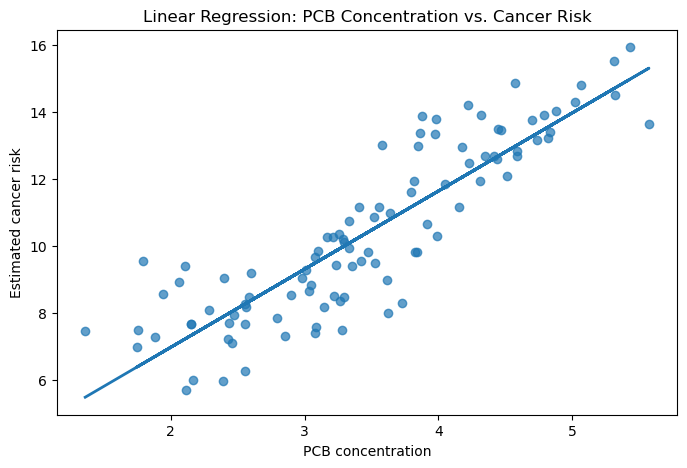

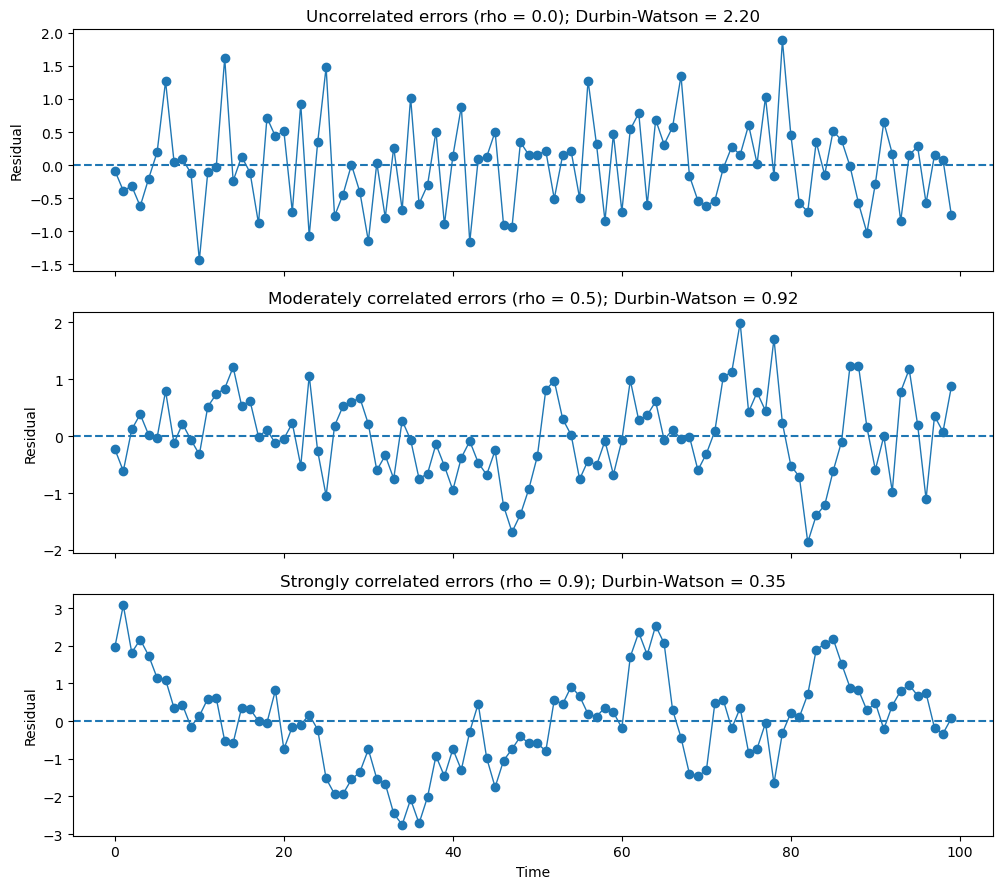

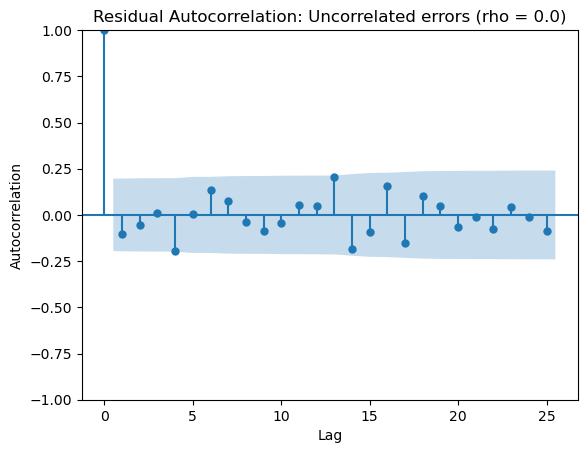

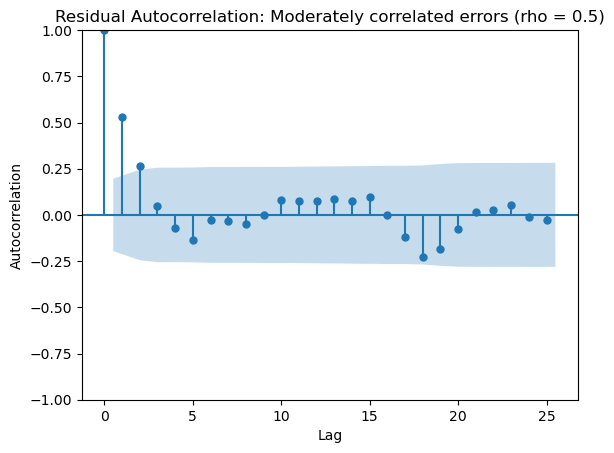

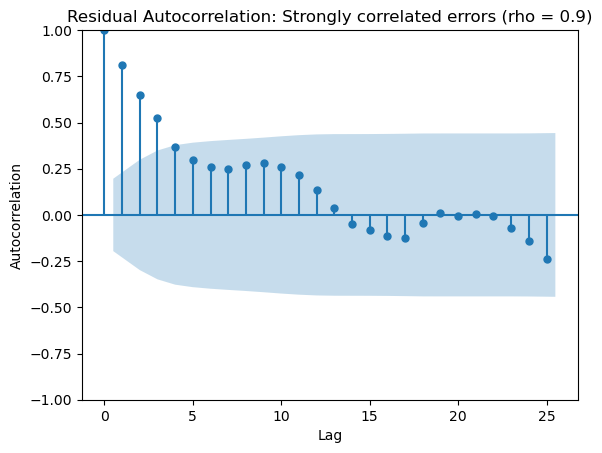

Naive OLS standard errors:
const                0.461987
pcb_concentration    0.128643
dtype: float64

HAC robust standard errors:
[0.87078768 0.22114419]

Naive OLS p-values:
const                2.504954e-06
pcb_concentration    4.600156e-33
dtype: float64

HAC robust p-values:
[9.30447254e-03 8.01284788e-18]


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.stats.stattools import durbin_watson

np.random.seed(42)

# ---------------------------------------------------------
# Function to simulate PCB concentration and cancer risk data
# with different levels of correlation in the error terms
# ---------------------------------------------------------

def simulate_pcb_data(rho, n=100):
    """
    rho controls correlation between adjacent errors:
    rho = 0.0 means uncorrelated errors
    rho = 0.5 means moderately correlated errors
    rho = 0.9 means strongly correlated errors
    """

    time = np.arange(n)

    # Synthetic PCB concentration over time
    pcb = 2 + 0.03 * time + np.random.normal(0, 0.4, n)

    # Generate correlated errors using an AR(1) process
    errors = np.zeros(n)
    noise = np.random.normal(0, 0.7, n)

    for t in range(1, n):
        errors[t] = rho * errors[t - 1] + noise[t]

    # True linear relationship
    cancer_risk = 5 + 1.8 * pcb + errors

    df = pd.DataFrame({
        "time": time,
        "pcb_concentration": pcb,
        "cancer_risk": cancer_risk
    })

    # Fit ordinary least squares regression
    X = sm.add_constant(df["pcb_concentration"])
    model = sm.OLS(df["cancer_risk"], X).fit()

    df["predicted_risk"] = model.predict(X)
    df["residuals"] = model.resid

    return df, model


# ---------------------------------------------------------
# Simulate three datasets with different error correlations
# ---------------------------------------------------------

correlations = {
    "Uncorrelated errors (rho = 0.0)": 0.0,
    "Moderately correlated errors (rho = 0.5)": 0.5,
    "Strongly correlated errors (rho = 0.9)": 0.9
}

results = {}

for label, rho in correlations.items():
    df, model = simulate_pcb_data(rho)
    results[label] = {
        "data": df,
        "model": model,
        "durbin_watson": durbin_watson(df["residuals"])
    }


# ---------------------------------------------------------
# Plot 1: Regression relationship for the strongest case
# ---------------------------------------------------------

strong_label = "Strongly correlated errors (rho = 0.9)"
strong_df = results[strong_label]["data"]

plt.figure(figsize=(8, 5))
plt.scatter(
    strong_df["pcb_concentration"],
    strong_df["cancer_risk"],
    alpha=0.7
)
plt.plot(
    strong_df["pcb_concentration"],
    strong_df["predicted_risk"],
    linewidth=2
)
plt.xlabel("PCB concentration")
plt.ylabel("Estimated cancer risk")
plt.title("Linear Regression: PCB Concentration vs. Cancer Risk")
plt.show()


# ---------------------------------------------------------
# Plot 2: Residuals over time for all three cases
# This is the key plot for illustrating correlated errors.
# ---------------------------------------------------------

fig, axes = plt.subplots(3, 1, figsize=(10, 9), sharex=True)

for ax, (label, result) in zip(axes, results.items()):
    df = result["data"]

    ax.plot(df["time"], df["residuals"], marker="o", linewidth=1)
    ax.axhline(0, linestyle="--")
    ax.set_ylabel("Residual")
    ax.set_title(
        f"{label}; Durbin-Watson = {result['durbin_watson']:.2f}"
    )

axes[-1].set_xlabel("Time")
plt.tight_layout()
plt.show()


# ---------------------------------------------------------
# Plot 3: Autocorrelation plots for residuals
# Optional confirmation of the visual pattern.
# ---------------------------------------------------------

for label, result in results.items():
    df = result["data"]

    plot_acf(df["residuals"], lags=25)
    plt.title(f"Residual Autocorrelation: {label}")
    plt.xlabel("Lag")
    plt.ylabel("Autocorrelation")
    plt.show()


# ---------------------------------------------------------
# Optional: compare standard errors for the strong case
# This shows why correlated errors are a problem.
# ---------------------------------------------------------

strong_model = results[strong_label]["model"]

hac_model = strong_model.get_robustcov_results(
    cov_type="HAC",
    maxlags=4
)

print("Naive OLS standard errors:")
print(strong_model.bse)

print("\nHAC robust standard errors:")
print(hac_model.bse)

print("\nNaive OLS p-values:")
print(strong_model.pvalues)

print("\nHAC robust p-values:")
print(hac_model.pvalues)

The plots show that as the correlation among error terms increases, the residuals display stronger “tracking,” meaning adjacent residuals tend to have similar values rather than appearing randomly scattered. This violates the linear regression assumption of independent errors and can make standard errors, confidence intervals, and p-values overly optimistic. The autocorrelation plots provide additional evidence that the residuals are increasingly correlated over time.

## 2. Non-constant Variance of Error Terms (Heteroscedasticity)

Non-constant variance of error terms refers to instances where variances in the error terms may change with the value of the response. This problem violates another assumption from linear regression models which states that variances in error terms are constant. This issue is important because it is tied to hypothesis tests, standard errors, and confidence intervals. One way to identify heteroscedasticity in the data is the presence of a funnel shape in the residual plot. There are two ways to address heteroscedasticity, according to section 3.3.3 of the text. One possible solution is to transform the response by applying a concave function such as the log or root square of the response. Alternatively, when we have a good idea of what the value of the response is, the solution is to fit the model using weighted least squares, where weights are proportional to the inverse variances.

                            OLS Regression Results                            
Dep. Variable:            cancer_risk   R-squared:                       0.889
Model:                            OLS   Adj. R-squared:                  0.888
Method:                 Least Squares   F-statistic:                     1181.
Date:                Sat, 25 Apr 2026   Prob (F-statistic):           1.95e-72
Time:                        00:11:54   Log-Likelihood:                -345.59
No. Observations:                 150   AIC:                             695.2
Df Residuals:                     148   BIC:                             701.2
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
const                 2.7662      0.44

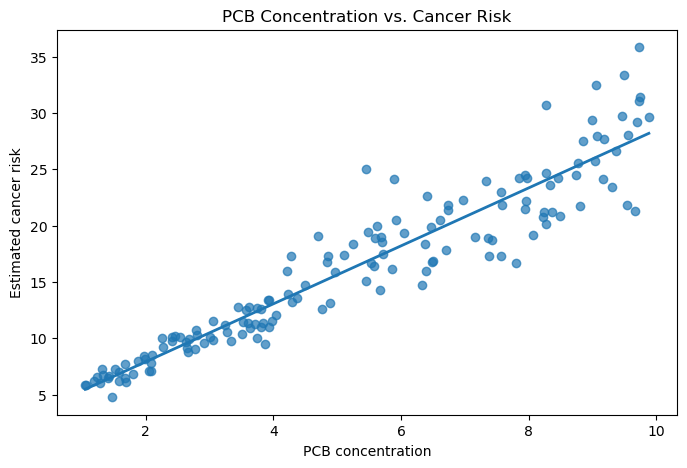

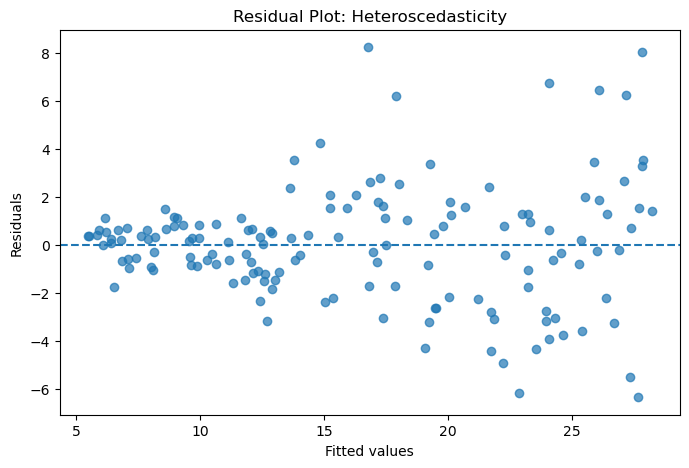

                            OLS Regression Results                            
Dep. Variable:        log_cancer_risk   R-squared:                       0.897
Model:                            OLS   Adj. R-squared:                  0.897
Method:                 Least Squares   F-statistic:                     1296.
Date:                Sat, 25 Apr 2026   Prob (F-statistic):           4.32e-75
Time:                        00:11:54   Log-Likelihood:                 68.933
No. Observations:                 150   AIC:                            -133.9
Df Residuals:                     148   BIC:                            -127.8
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
const                 1.7898      0.02

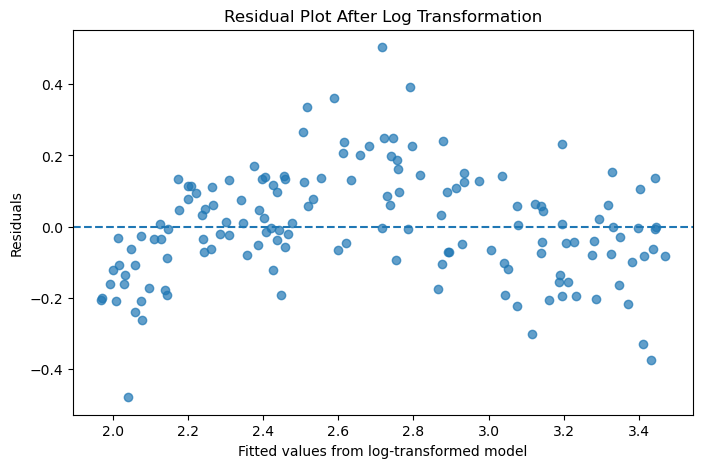

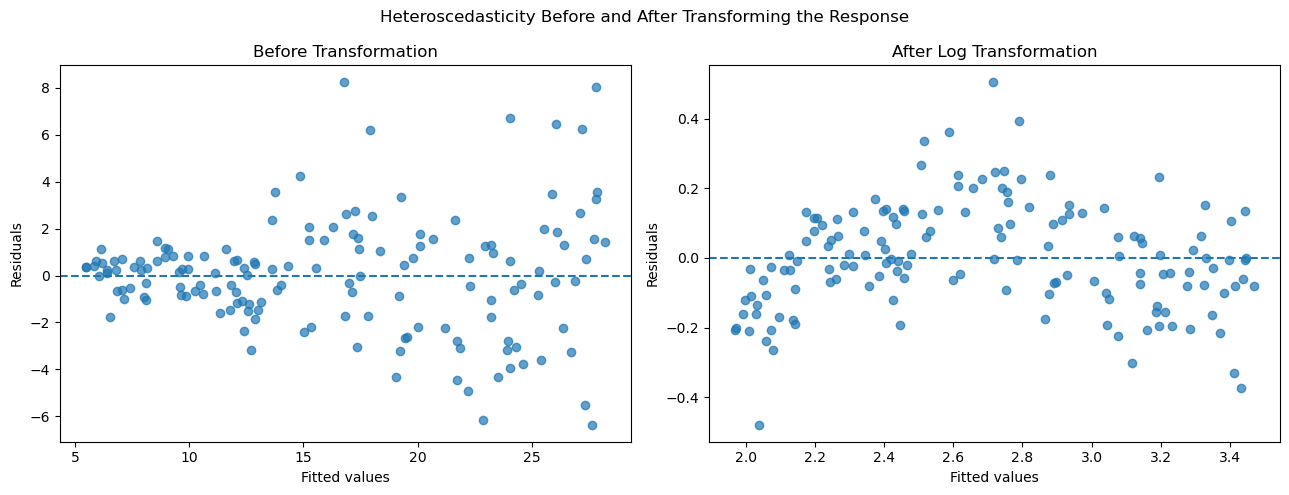

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.stats.diagnostic import het_breuschpagan

np.random.seed(42)

# 1. Generate synthetic PCB concentration and cancer risk data

n = 150

# PCB concentration
pcb = np.random.uniform(1, 10, n)

# Heteroscedastic errors:
# The error variance increases as PCB concentration increases.
error_sd = 0.4 * pcb
errors = np.random.normal(0, error_sd)

# True relationship:
# Cancer risk increases with PCB concentration.
cancer_risk = 3 + 2.5 * pcb + errors

df = pd.DataFrame({
    "pcb_concentration": pcb,
    "cancer_risk": cancer_risk
})

# 2. Fit ordinary least squares regression

X = sm.add_constant(df["pcb_concentration"])
ols_model = sm.OLS(df["cancer_risk"], X).fit()

df["fitted"] = ols_model.fittedvalues
df["residuals"] = ols_model.resid

print(ols_model.summary())

# Breusch-Pagan test for heteroscedasticity
bp_test = het_breuschpagan(df["residuals"], X)

print("\nBreusch-Pagan test:")
print(f"LM statistic: {bp_test[0]:.3f}")
print(f"LM p-value: {bp_test[1]:.5f}")
print(f"F statistic: {bp_test[2]:.3f}")
print(f"F p-value: {bp_test[3]:.5f}")

# 3. Plot the regression relationship

plt.figure(figsize=(8, 5))
plt.scatter(df["pcb_concentration"], df["cancer_risk"], alpha=0.7)
plt.plot(
    np.sort(df["pcb_concentration"]),
    ols_model.predict(sm.add_constant(np.sort(df["pcb_concentration"]))),
    linewidth=2
)
plt.xlabel("PCB concentration")
plt.ylabel("Estimated cancer risk")
plt.title("PCB Concentration vs. Cancer Risk")
plt.show()

# 4. Key plot: residuals vs fitted values
# This shows the funnel shape caused by non-constant variance.

plt.figure(figsize=(8, 5))
plt.scatter(df["fitted"], df["residuals"], alpha=0.7)
plt.axhline(0, linestyle="--")
plt.xlabel("Fitted values")
plt.ylabel("Residuals")
plt.title("Residual Plot: Heteroscedasticity")
plt.show()

# 5. Address the issue using a log transformation of Y
# This follows the ISLP suggestion for reducing heteroscedasticity.

df["log_cancer_risk"] = np.log(df["cancer_risk"])

log_model = sm.OLS(df["log_cancer_risk"], X).fit()

df["log_fitted"] = log_model.fittedvalues
df["log_residuals"] = log_model.resid

print(log_model.summary())

# Breusch-Pagan test after log transformation
bp_test_log = het_breuschpagan(df["log_residuals"], X)

print("\nBreusch-Pagan test after log transformation:")
print(f"LM statistic: {bp_test_log[0]:.3f}")
print(f"LM p-value: {bp_test_log[1]:.5f}")
print(f"F statistic: {bp_test_log[2]:.3f}")
print(f"F p-value: {bp_test_log[3]:.5f}")

# 6. Residual plot after log transformation


plt.figure(figsize=(8, 5))
plt.scatter(df["log_fitted"], df["log_residuals"], alpha=0.7)
plt.axhline(0, linestyle="--")
plt.xlabel("Fitted values from log-transformed model")
plt.ylabel("Residuals")
plt.title("Residual Plot After Log Transformation")
plt.show()

# 7. Side-by-side comparison

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].scatter(df["fitted"], df["residuals"], alpha=0.7)
axes[0].axhline(0, linestyle="--")
axes[0].set_xlabel("Fitted values")
axes[0].set_ylabel("Residuals")
axes[0].set_title("Before Transformation")

axes[1].scatter(df["log_fitted"], df["log_residuals"], alpha=0.7)
axes[1].axhline(0, linestyle="--")
axes[1].set_xlabel("Fitted values")
axes[1].set_ylabel("Residuals")
axes[1].set_title("After Log Transformation")

plt.suptitle("Heteroscedasticity Before and After Transforming the Response")
plt.tight_layout()
plt.show()

The plots show heteroscedasticity through a funnel-shaped residual pattern, where the spread of residuals increases as fitted cancer risk values become larger. After applying a log transformation to the response variable, the residual spread becomes more even. Thus, the log transformation reduced the non-constant variance problem. These plots illustrate why heteroscedasticity can make ordinary linear regression inference unreliable and how transforming the response can help address it.

## 3. Collinearity

Collinearity, as defined by the text, refers to the instance where two or more predictor variables are closely related to one another. Not addressing collinearity in regression models can obscure how each predictor is individually associated with the response. Specifically, the the validity of the hypothesis test is reduced by collinearity, since it increases the standard errors of the coefficients. Collinearity can be detected by a contour plot of the residual sum of squares (RSS) associated with different possible coefficient estimates for the regression of the response on the predictor variables. The text presents two approaches to address collinearity. The first is to remove one of the problematic variables from the regression model. The second solution is to treat the collinear variables as a single predictor by combining said problematic variables. 

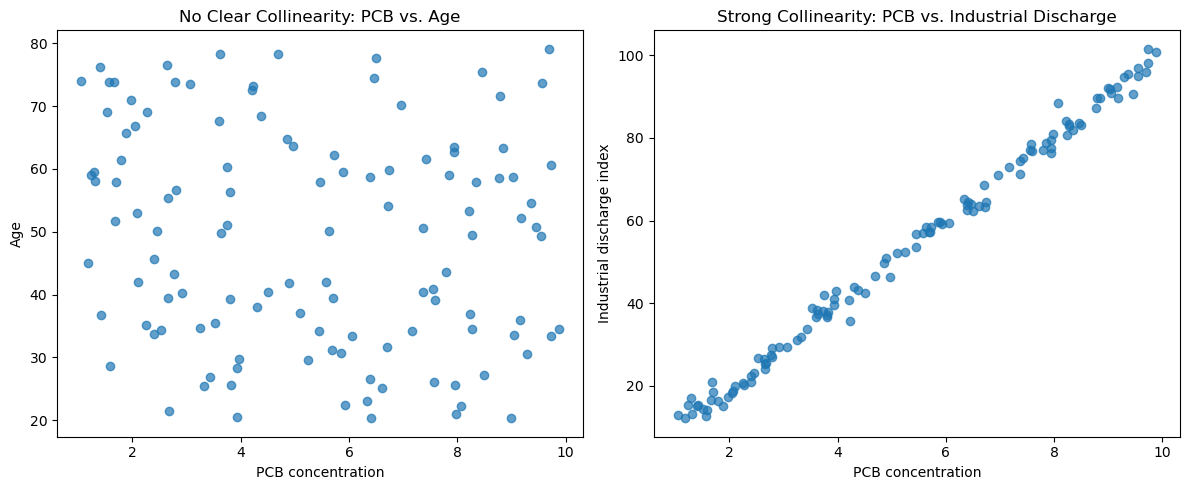

Correlation matrix:
                      pcb_concentration       age  industrial_discharge
pcb_concentration              1.000000 -0.151658              0.997123
age                           -0.151658  1.000000             -0.162354
industrial_discharge           0.997123 -0.162354              1.000000

Model A: PCB + Age
                            OLS Regression Results                            
Dep. Variable:            cancer_risk   R-squared:                       0.930
Model:                            OLS   Adj. R-squared:                  0.929
Method:                 Least Squares   F-statistic:                     776.4
Date:                Sat, 25 Apr 2026   Prob (F-statistic):           2.91e-68
Time:                        00:45:28   Log-Likelihood:                -241.09
No. Observations:                 120   AIC:                             488.2
Df Residuals:                     117   BIC:                             496.5
Df Model:                           2   

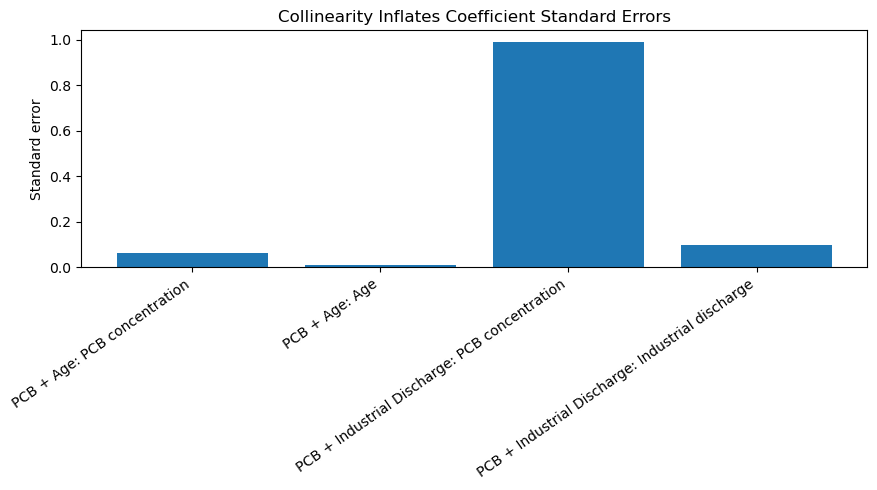


Reduced Model: PCB only
                            OLS Regression Results                            
Dep. Variable:            cancer_risk   R-squared:                       0.899
Model:                            OLS   Adj. R-squared:                  0.898
Method:                 Least Squares   F-statistic:                     1046.
Date:                Sat, 25 Apr 2026   Prob (F-statistic):           1.76e-60
Time:                        00:45:28   Log-Likelihood:                -263.27
No. Observations:                 120   AIC:                             530.5
Df Residuals:                     118   BIC:                             536.1
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
const        

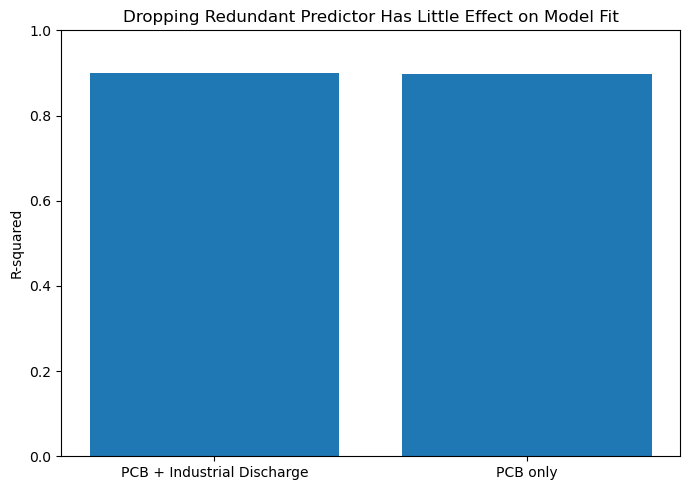

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

np.random.seed(42)

# 1. Generate synthetic environmental data

n = 120

# Predictor 1: PCB concentration
pcb = np.random.uniform(1, 10, n)

# Predictor 2: age of nearby residents
# This is intentionally NOT strongly related to PCB concentration.
age = np.random.uniform(20, 80, n)

# Predictor 3: industrial discharge index
# This is intentionally HIGHLY related to PCB concentration.
industrial_discharge = 10 * pcb + np.random.normal(0, 2, n)

# Response: estimated cancer risk
# The true relationship depends mostly on PCB concentration and age.
error = np.random.normal(0, 2, n)
cancer_risk = 5 + 2.5 * pcb + 0.08 * age + error

df = pd.DataFrame({
    "pcb_concentration": pcb,
    "age": age,
    "industrial_discharge": industrial_discharge,
    "cancer_risk": cancer_risk
})

# 2. Visualize predictor relationships

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].scatter(df["pcb_concentration"], df["age"], alpha=0.7)
axes[0].set_xlabel("PCB concentration")
axes[0].set_ylabel("Age")
axes[0].set_title("No Clear Collinearity: PCB vs. Age")

axes[1].scatter(df["pcb_concentration"], df["industrial_discharge"], alpha=0.7)
axes[1].set_xlabel("PCB concentration")
axes[1].set_ylabel("Industrial discharge index")
axes[1].set_title("Strong Collinearity: PCB vs. Industrial Discharge")

plt.tight_layout()
plt.show()

print("Correlation matrix:")
print(df[["pcb_concentration", "age", "industrial_discharge"]].corr())

# 3. Fit two regression models

# Model A: cancer risk predicted by PCB concentration and age
X_age = sm.add_constant(df[["pcb_concentration", "age"]])
model_age = sm.OLS(df["cancer_risk"], X_age).fit()

# Model B: cancer risk predicted by PCB concentration and industrial discharge
X_discharge = sm.add_constant(df[["pcb_concentration", "industrial_discharge"]])
model_discharge = sm.OLS(df["cancer_risk"], X_discharge).fit()

print("\nModel A: PCB + Age")
print(model_age.summary())

print("\nModel B: PCB + Industrial Discharge")
print(model_discharge.summary())

# 4. Compare VIF values

def calculate_vif(X):
    """
    Calculate VIF values for a set of predictors.
    If there is only one predictor, VIF = 1 by definition.
    """
    vif_data = pd.DataFrame()
    vif_data["Predictor"] = X.columns

    if X.shape[1] == 1:
        vif_data["VIF"] = [1.0]
    else:
        vif_data["VIF"] = [
            variance_inflation_factor(X.values, i)
            for i in range(X.shape[1])
        ]

    return vif_data

print("\nVIF for Model A: PCB + Age")
print(calculate_vif(X_age.drop(columns="const")))

print("\nVIF for Model B: PCB + Industrial Discharge")
print(calculate_vif(X_discharge.drop(columns="const")))

# 5. Compare coefficient estimates and standard errors

comparison = pd.DataFrame({
    "Model": [
        "PCB + Age",
        "PCB + Age",
        "PCB + Industrial Discharge",
        "PCB + Industrial Discharge"
    ],
    "Predictor": [
        "PCB concentration",
        "Age",
        "PCB concentration",
        "Industrial discharge"
    ],
    "Coefficient": [
        model_age.params["pcb_concentration"],
        model_age.params["age"],
        model_discharge.params["pcb_concentration"],
        model_discharge.params["industrial_discharge"]
    ],
    "Standard Error": [
        model_age.bse["pcb_concentration"],
        model_age.bse["age"],
        model_discharge.bse["pcb_concentration"],
        model_discharge.bse["industrial_discharge"]
    ],
    "p-value": [
        model_age.pvalues["pcb_concentration"],
        model_age.pvalues["age"],
        model_discharge.pvalues["pcb_concentration"],
        model_discharge.pvalues["industrial_discharge"]
    ],
    "R-squared": [
        model_age.rsquared,
        model_age.rsquared,
        model_discharge.rsquared,
        model_discharge.rsquared
    ]
})

print("\nCoefficient comparison:")
print(comparison)

# 6. Bar plot of standard errors
# This shows that collinearity inflates uncertainty.

plt.figure(figsize=(9, 5))
plt.bar(
    comparison["Model"] + ": " + comparison["Predictor"],
    comparison["Standard Error"]
)
plt.xticks(rotation=35, ha="right")
plt.ylabel("Standard error")
plt.title("Collinearity Inflates Coefficient Standard Errors")
plt.tight_layout()
plt.show()

# 7. Address the issue: drop the redundant collinear predictor

# Since industrial discharge is highly redundant with PCB concentration,
# we drop industrial discharge and keep PCB concentration.
X_reduced = sm.add_constant(df[["pcb_concentration"]])
model_reduced = sm.OLS(df["cancer_risk"], X_reduced).fit()

print("\nReduced Model: PCB only")
print(model_reduced.summary())

print("\nVIF for Reduced Model: PCB only")
print(calculate_vif(X_reduced.drop(columns="const")))

# 8. Compare model fit before and after dropping collinear predictor

r2_comparison = pd.DataFrame({
    "Model": [
        "PCB + Industrial Discharge",
        "PCB only"
    ],
    "R-squared": [
        model_discharge.rsquared,
        model_reduced.rsquared
    ]
})

print("\nR-squared comparison:")
print(r2_comparison)

plt.figure(figsize=(7, 5))
plt.bar(r2_comparison["Model"], r2_comparison["R-squared"])
plt.ylim(0, 1)
plt.ylabel("R-squared")
plt.title("Dropping Redundant Predictor Has Little Effect on Model Fit")
plt.tight_layout()
plt.show()

The plots show that PCB concentration and age are not strongly related, but PCB concentration and industrial discharge are highly collinear. In the collinear model, the predictors contain overlapping information, which inflates standard errors and makes individual coefficient estimates less reliable even when the overall model fit remains strong. Dropping the redundant industrial discharge predictor reduced the collinearity problem with little loss in model fit.

## Generative AI Reflection

which tool did you use, what prompts did you give it, and how many iterations did it take to get working code? Note any mistakes the AI made and how you identified and fixed them.

I used ChatGPT Instant for this task. The prompts I gave it for each problem type was to generate python code that illustrates a working example that closely fit the example in the book but in an environmental context. I specified the example variables used rather than have ChatGPT make one for me, such as PCB concentrations and cancer risk. It took two iterations to generate working code, the first generated working pltos and a second prompt was applied remove demonstrations of topics outside of what has been discussed in the class.